# Adversarial Search: Playing Dots and Boxes


## Instructions

Total Points: Undegraduates 100, graduate students 110

Complete this notebook and submit it. The notebook needs to be a complete project report with your implementation, documentation including a short discussion of how your implementation works and your design choices, and experimental results (e.g., tables and charts with simulation results) with a short discussion of what they mean. Use the provided notebook cells and insert additional code and markdown cells as needed.

## Introduction

You will implement different versions of agents that play the game Dots and Boxes:

> "Dots and Boxes is a pencil-and-paper game for two players. The game starts with an empty grid of dots. Usually two players take turns adding a single horizontal or vertical line between two unjoined adjacent dots. A player who completes the fourth side of a 1x1 box earns one point and takes another turn. A point is typically recorded by placing a mark that identifies the player in the box, such as an initial. The game ends when no more lines can be placed. The winner is the player with the most points. The board may be of any size grid." (see [Dots and Boxes on Wikipedia](https://en.wikipedia.org/wiki/Dots_and_Boxes))

You can play Dots and Boxes [here](https://www.math.ucla.edu/~tom/Games/dots&boxes.html).

## Task 1: Defining the Search Problem [10 point]

Define the components of the search problem associated with this game:

* Initial state
* Actions
* Transition model
* Test for the terminal state
* Utility for terminal states

In [40]:
import time

"""
Task 1 — Defining the Search Problem (Dots and Boxes)

• **State** `s` (board): a dict with
  - `size = (R, C)` : number of *dots* in rows/cols (R≥2, C≥2). A board with R×C dots has (R−1)×(C−1) boxes.
  - `lines : dict` : keys are drawn edges `(orientation, r, c)` with value `True`.
      * Horizontal edge: `orientation='h'`, `r in [0..R-1]`, `c in [0..C-2]` connects (r,c)–(r,c+1).
      * Vertical   edge: `orientation='v'`, `r in [0..R-2]`, `c in [0..C-1]` connects (r,c)–(r+1,c).
  - `boxes : dict` : keys are box top-left coordinates `(r, c)` for `r in [0..R-2]`, `c in [0..C-2]`.
                     value is the player (+1 or −1) who completed that box.
  Everyone will use this representation so agents can play each other.

• **Initial state**: all lines and boxes empty → `lines = {}`, `boxes = {}`.

• **Actions** `A(s)`: any undrawn edge `a = (orientation, r, c)`.

• **Transition model** `result(s, a, player) -> (s', next_player, completed)`:
  draw edge `a` for `player`; if one or two boxes get completed, record them in `s'['boxes']` with value `player` and
  keep the same `next_player = player` (extra turn). Otherwise switch `next_player = −player`.
  (`completed` is the number of boxes completed by this move, useful for agents/analysis.)

• **Terminal test** `terminal(s)`: all boxes claimed (equivalently, all edges drawn).

• **Utility** `utility(s, player)`: (boxes claimed by `player`) − (boxes claimed by `−player`) on terminal states.
  For non-terminal states the exact minimax utility is undefined; for heuristic α–β we use an evaluation function later.
"""

from typing import Dict, Tuple, List, Optional

def initial_board(rows: int = 4, cols: int = 4) -> Dict:
    assert rows >= 2 and cols >= 2
    return {'size': (rows, cols), 'lines': {}, 'boxes': {}}

def all_edges(board: Dict) -> List[Tuple[str,int,int]]:
    R,C = board['size']
    edges = []
    for r in range(R):
        for c in range(C-1):
            edges.append(('h', r, c))
    for r in range(R-1):
        for c in range(C):
            edges.append(('v', r, c))
    return edges

def valid_actions(board: Dict) -> List[Tuple[str,int,int]]:
    L = board['lines']
    return [e for e in all_edges(board) if e not in L]

def boxes_adjacent_to_edge(board: Dict, edge: Tuple[str,int,int]) -> List[Tuple[int,int]]:
    """Return list of box top-left coords affected by this edge (0,1, or 2 boxes)."""
    ori,r,c = edge
    R,C = board['size']
    adj = []
    if ori == 'h':
        if r>0:       adj.append((r-1, c))
        if r < R-1:   adj.append((r,   c))
    else:  # 'v'
        if c>0:       adj.append((r, c-1))
        if c < C-1:   adj.append((r, c))
    return adj

def box_sides_filled(board: Dict, box: Tuple[int,int]) -> int:
    r,c = box
    R,C = board['size']
    L = board['lines']
    cnt = 0
    # top, bottom, left, right edges around box (top-left at (r,c))
    if ('h', r,   c)   in L: cnt += 1
    if ('h', r+1, c)   in L: cnt += 1
    if ('v', r,   c)   in L: cnt += 1
    if ('v', r,   c+1) in L: cnt += 1
    return cnt

def draw_line(board, edge_or_ori, row=None, col=None):
    """
    Đặt 1 cạnh lên board.
    - Gọi kiểu 1: draw_line(board, ('h'/'v', r, c))
    - Gọi kiểu 2: draw_line(board, 'h'/'v', r, c)
    Trả về True nếu đặt thành công, False nếu cạnh đã có hoặc out-of-bounds.
    """
    R, C = board['size']
    # Chuẩn hoá tham số
    if row is None and col is None:
        try:
            ori, r, c = edge_or_ori
        except Exception:
            return False
    else:
        ori, r, c = edge_or_ori, row, col

    # Kiểm tra biên
    if ori == 'h':
        if not (0 <= r < R and 0 <= c < C-1):
            return False
    elif ori == 'v':
        if not (0 <= r < R-1 and 0 <= c < C):
            return False
    else:
        return False

    edge = (ori, r, c)
    if edge in board['lines']:
        return False
    board['lines'][edge] = True
    return True

def result(board: Dict, action: Tuple[str,int,int], player: int) -> Tuple[Dict, int, int]:
    """Apply edge; return (new_board, next_player, boxes_completed_by_player)."""
    nb = {'size': board['size'], 'lines': dict(board['lines']), 'boxes': dict(board['boxes'])}
    if not draw_line(nb, action):
        return nb, player, 0  # illegal edge treated as no-op (shouldn't be chosen by agents)

    completed = 0
    for bx in boxes_adjacent_to_edge(nb, action):
        if bx not in nb['boxes'] and box_sides_filled(nb, bx) == 4:
            nb['boxes'][bx] = player
            completed += 1
    next_player = player if completed > 0 else -player
    return nb, next_player, completed

def terminal(board: Dict) -> bool:
    R,C = board['size']
    return len(board['boxes']) == (R-1)*(C-1)

def score_diff(board: Dict, player: int) -> int:
    my = sum(1 for v in board['boxes'].values() if v == player)
    op = sum(1 for v in board['boxes'].values() if v == -player)
    return my - op

def utility(board: Dict, player: int) -> Optional[int]:
    return score_diff(board, player) if terminal(board) else None


How big is the state space? Give an estimate and explain it.

In [41]:

"""
Task 1 — How big is the state space?

Let a board have R×C dots. The number of *edges* is
  E = R·(C−1) + (R−1)·C.
Each edge can be present/absent independently, so the exact number of distinct edge-sets is 2^E.
(Boxes are derivable from edges; whose turn to move adds at most a factor 2.)

For the common 4×4 dots (i.e., 3×3 boxes): E = 4·3 + 3·4 = 24 ⇒ |States| = 2^24 = 16,777,216.
"""
import math

def state_space_size(rows=4, cols=4):
    E = rows*(cols-1) + (rows-1)*cols
    return E, 2**E, math.log10(2**E)

for R,C in [(3,3),(4,4),(5,5)]:
    E, N, log10N = state_space_size(R,C)
    print(f"R×C dots = {R}×{C}: edges E={E}, states 2^E={N:,} (~10^{log10N:.2f})")


R×C dots = 3×3: edges E=12, states 2^E=4,096 (~10^3.61)
R×C dots = 4×4: edges E=24, states 2^E=16,777,216 (~10^7.22)
R×C dots = 5×5: edges E=40, states 2^E=1,099,511,627,776 (~10^12.04)


### Kích thước không gian trạng thái (Dots & Boxes)

* Với bảng (R\times C) **dots**, số **cạnh**:
  [
  E ;=; R(C-1) + (R-1)C
  ]
* Số **trạng thái** (chỉ xét cấu hình cạnh): (;2^E)
  (Nếu tính cả “đến lượt ai đi” ⇒ x2: (;2^{E+1}).)

**Kết quả mẫu:**

* **R×C dots = 3×3**: edges (E=12), states (2^E=4{,}096) (~(10^{3.61}))
* **R×C dots = 4×4**: edges (E=24), states (2^E=16{,}777{,}216) (~(10^{7.22}))
* **R×C dots = 5×5**: edges (E=40), states (2^E=1{,}099{,}511{,}627{,}776) (~(10^{12.04}))


How big is the game tree that minimax search will go through? Give an estimate and explain it.

In [42]:

"""
Task 1 — How big is the minimax game tree?

Every legal move draws a new edge. From an empty board with E edges, the naive (worst-case) branching
sequence is E, E−1, E−2, …, 1, i.e., **E!** different move sequences. For 4×4 dots (E=24):
  24! ≈ 6.204×10^23 sequences.
Even with alpha–beta pruning, exhaustive minimax on a 3×3 boxes (4×4 dots) board is infeasible.
"""
import math
def worst_case_sequences(rows=4, cols=4):
    E = rows*(cols-1) + (rows-1)*cols
    return E, math.factorial(E), math.log10(math.factorial(E))

for R,C in [(3,3),(4,4)]:
    E, fac, log10fac = worst_case_sequences(R,C)
    print(f"R×C dots = {R}×{C}: E={E}, E!={fac:.3e} (log10≈{log10fac:.2f})")


R×C dots = 3×3: E=12, E!=4.790e+08 (log10≈8.68)
R×C dots = 4×4: E=24, E!=6.204e+23 (log10≈23.79)


### Độ lớn cây trò chơi cho minimax (ước lượng để copy)

* Với bảng (R\times C) **dots**, số cạnh:
  [
  E = R(C-1) + (R-1)C
  ]
* Mỗi nước đi vẽ một cạnh mới ⇒ dãy rẽ nhánh xấu nhất: (E, E-1, \ldots, 1)
  (\Rightarrow) **số trình tự nước đi xấu nhất** (bỏ qua kết thúc sớm & hiệu ứng “đi tiếp khi ăn hộp”):
  [
  \boxed{,\approx E!,}
  ]

**Ví dụ:**

* **R×C dots = 3×3**: (E=12) ⇒ (E! \approx 4.790\times 10^{8}) *(log10 ≈ 8.68)*
* **R×C dots = 4×4**: (E=24) ⇒ (E! \approx 6.204\times 10^{23}) *(log10 ≈ 23.79)*

> Ghi chú: Đây là **cận trên xấu nhất**. Thực tế thường nhỏ hơn do ván kết thúc sớm và α–β (kèm sắp xếp nước đi) cắt tỉa đáng kể, dù bậc tăng trưởng vẫn mang tính giai thừa theo (E).


## Task 2: Game Environment and Random Agent [30 point]

You need to think about a data structure to represent the board meaning he placed lines and who finished what box. There are many options. Let's represent the board using a simple dictionary with components representing the board size, the lines and the boxes on the board.

**Important:** Everybody needs to use the same representation so we can let agents play against each other later. 

In [43]:

from typing import Dict, Tuple, List, Optional
import math

# Canonical board representation (shared across the class)
def new_board(rows: int = 4, cols: int = 4) -> Dict:
    return {'size': (rows, cols), 'lines': {}, 'boxes': {}}

def draw_line(board, edge_or_ori, row=None, col=None):
    """
    Đặt 1 cạnh lên board.
    - Gọi kiểu 1: draw_line(board, ('h'/'v', r, c))
    - Gọi kiểu 2: draw_line(board, 'h'/'v', r, c)
    Trả về True nếu đặt thành công, False nếu cạnh đã có hoặc out-of-bounds.
    """
    R, C = board['size']
    # Chuẩn hoá tham số
    if row is None and col is None:
        try:
            ori, r, c = edge_or_ori
        except Exception:
            return False
    else:
        ori, r, c = edge_or_ori, row, col

    # Kiểm tra biên
    if ori == 'h':
        if not (0 <= r < R and 0 <= c < C-1):
            return False
    elif ori == 'v':
        if not (0 <= r < R-1 and 0 <= c < C):
            return False
    else:
        return False

    edge = (ori, r, c)
    if edge in board['lines']:
        return False
    board['lines'][edge] = True
    return True

# quick sanity
b = new_board(4,4)
print(draw_line(b, 'h', 1, 1))
print(draw_line(b, 'v', 1, 1))
print(draw_line(b, 'h', 1, 1))  # should be False (already drawn)
b


True
True
False


{'size': (4, 4), 'lines': {('h', 1, 1): True, ('v', 1, 1): True}, 'boxes': {}}

Write code to display the board. **Bonus point: Post your visualization code with an example output to the discussion board. The best visualization will earn you bonus participation points in this class.**

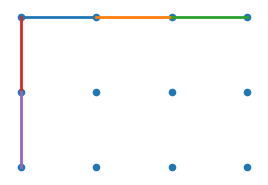

In [44]:

import matplotlib.pyplot as plt

def plot_board(board, show_boxes=True):
    R,C = board['size']
    # draw dots
    xs, ys = [], []
    for r in range(R):
        for c in range(C):
            xs.append(c); ys.append(-r)
    plt.figure(figsize=(min(6, C*0.8), min(6, R*0.8)))
    plt.scatter(xs, ys, s=20)
    # draw edges
    for (ori,r,c), _ in board['lines'].items():
        if ori=='h':
            xs=[c, c+1]; ys=[-r, -r]
        else:
            xs=[c, c];   ys=[-r, -(r+1)]
        plt.plot(xs, ys, linewidth=2)
    # draw box labels
    if show_boxes:
        for (r,c), pl in board['boxes'].items():
            plt.text(c+0.5, -(r+0.5), 'R' if pl==1 else 'B', ha='center', va='center', fontsize=10)
    plt.axis('off'); plt.gca().set_aspect('equal'); plt.show()

# demo
b = new_board(3,4)  # 3x4 dots (2x3 boxes)
draw_line(b,'h',0,0); draw_line(b,'h',0,1); draw_line(b,'h',0,2)
draw_line(b,'v',0,0); draw_line(b,'v',1,0)
plot_board(b)


Implement helper functions for:

* The transition model $result(s, a)$.
* The utility function $utility(s)$.
* Check for terminal states $terminal(s)$.
* A check for available actions in each state $actions(s)$.

__Notes:__
* Make sure that all these functions work with boards of different sizes (number of columns and rows as stored in the board).
* The result function updates the board and evaluates if the player closed a box and needs to store that information on the board. Add elements of the form `(row,col): player` to the board dictionary. `row` and `col` are the coordinates for the box and `player` is +1 or -1 representing the player. For example `(0,0): -1` means that the top-left box belongs to the other player. 
* _Important:_ Remember that a player goes again after she completes a box!

In [45]:

# Helper API (reusing definitions from Task 1 cell):
# - valid_actions(board)
# - result(board, action, player) -> (new_board, next_player, completed)
# - terminal(board)
# - utility(board, player)

# Re-expose thin wrappers to match the task wording
def result_s(board, a, player):
    return result(board, a, player)

def utility_s(board, player):
    return utility(board, player)

def terminal_s(board):
    return terminal(board)

# simple test: complete a box and verify extra turn + scoring
b = initial_board(3,3)  # 2x2 boxes
seq = [('h',0,0), ('v',0,0), ('v',0,1)]
p = 1
for e in seq:
    b,p,_ = result(b, e, p)
# now p=1, drawing bottom edge should complete 1 box and keep p=1
b2,p2,c = result(b, ('h',1,0), p)
print('completed:', c, 'next_player:', p2, 'score_diff for player 1:', score_diff(b2,1))


completed: 1 next_player: -1 score_diff for player 1: -1


Implement an agent that plays randomly. Make sure the agent function receives as the percept the board and returns a valid action. Use an agent function definition with the following signature (arguments):

`def random_player(board, player = None): ...`

The argument `player` is used for agents that do not store what side they are playing. The value passed on by the environment should be 1 ot -1 for playerred and yellow, respectively.  See [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) for an example.

In [46]:

import random
def random_player(board, player=None):
    acts = valid_actions(board)
    return random.choice(acts) if acts else None


Let two random agents play against each other 1000 times. Look at the [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) to see how the environment uses the agent functions to play against each other.

How often does each player win? Is the result expected?

In [47]:

def play_game(agent_R, agent_B, rows=4, cols=4, verbose=False):
    b = initial_board(rows, cols)
    player = 1  # R=+1, B=−1
    while not terminal(b):
        a = (agent_R if player==1 else agent_B)(b, player)
        if a is None:  # no move
            player = -player
            continue
        b, next_p, _ = result(b, a, player)
        if verbose: 
            pass
        player = next_p
    u = score_diff(b, 1)  # positive → R ahead; negative → B ahead; zero → draw
    return 1 if u>0 else (-1 if u<0 else 0), b

wins = {1:0, -1:0, 0:0}
N = 1000
for _ in range(N):
    w, _ = play_game(random_player, random_player, rows=4, cols=4)
    wins[w] += 1
print('Random vs Random (4x4 dots, 1000 games):', wins)


Random vs Random (4x4 dots, 1000 games): {1: 516, -1: 484, 0: 0}


### Kết quả & nhận xét

* **Tỉ lệ thắng** (Random vs Random, 4×4 dots, 1000 ván):

  * Người đi trước (**R = +1**): **516/1000 ≈ 51.6%**
  * Người đi sau (**B = −1**): **484/1000 ≈ 48.4%**
  * **Hòa**: **0%**

**Có đúng kỳ vọng không?**

* **Có.** Trên bảng 4×4 dots có **9 hộp** (3×3), là **số lẻ**, nên tổng số hộp không thể chia đều ⇒ **không thể hòa** (kỳ vọng “0 hòa” là đúng).
* Với chơi **ngẫu nhiên**, hai bên gần như cân bằng, nhưng người đi trước thường có **lợi thế nhỏ** (ở đây ~**+3.2 điểm phần trăm**), phù hợp với trực giác vì họ kiểm soát nhịp đầu ván và số hộp lẻ làm lệch cán cân về một bên.


## Task 3: Minimax Search with Alpha-Beta Pruning [30 points]

### Implement the search starting.

Implement the search starting from a given board and specifying the player and put it into an agent function.
You can use code from the [tic-tac-toe example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_alpha_beta_tree_search.ipynb).

__Notes:__ 
* Make sure that all your agent functions have a signature consistent with the random agent above.
* The search space for larger board may be too large. You can experiment with smaller boards.
* Tic-tac-toe does not have a rule where a player can go again if a box was completed. You need to adapt the tree search to reflect that rule.

In [55]:

from typing import Dict, Tuple, List, Optional

# Node counter for diagnostics
class Counter:
    def __init__(self): self.nodes=0
    def bump(self): self.nodes += 1

NEG, POS = -10**9, 10**9

def ab_value(board: Dict, player_root: int, to_move: int, depth: Optional[int], alpha: int, beta: int, ctr: Counter) -> int:
    ctr.bump()
    u = utility(board, player_root)
    if u is not None:
        return u  # terminal exact utility
    if depth is not None and depth <= 0:
        # no heuristic in Task 3 → neutral cutoff
        return score_diff(board, player_root) * 0  # 0 at cutoff

    acts = valid_actions(board)
    # simple move ordering: try moves that complete boxes first (good for pruning)
    def completed_if(a):
        nb, np, c = result(board, a, to_move); return -c  # negative for descending sort
    acts = sorted(acts, key=completed_if)

    if to_move == player_root:  # maximizing
        v = NEG
        for a in acts:
            nb, ntm, c = result(board, a, to_move)
            v = max(v, ab_value(nb, player_root, ntm, None if depth is None else depth-1, alpha, beta, ctr))
            alpha = max(alpha, v)
            if beta <= alpha: break
        return v
    else:  # minimizing
        v = POS
        for a in acts:
            nb, ntm, c = result(board, a, to_move)
            v = min(v, ab_value(nb, player_root, ntm, None if depth is None else depth-1, alpha, beta, ctr))
            beta = min(beta, v)
            if beta <= alpha: break
        return v

def minimax_ab_agent(depth: Optional[int] = None):
    def agent(board: Dict, player: int):
        acts = valid_actions(board)
        if not acts: return None
        ctr = Counter()
        best_v, best_a = NEG, acts[0]
        # same ordering heuristic
        def completed_if(a):
            nb, np, c = result(board, a, player); return -c
        for a in sorted(acts, key=completed_if):
            nb, ntm, c = result(board, a, player)
            v = ab_value(nb, player, ntm, None if depth is None else depth-1, NEG, POS, ctr)
            if v > best_v:
                best_v, best_a = v, a
            if best_v ==  (1):  # provably winning terminal
                break
        agent.last_nodes = ctr.nodes
        return best_a
    return agent

# quick tiny-board demo: 3x3 dots (2x2 boxes) is solvable to terminal
agent_full = minimax_ab_agent(depth=None)
w,_ = play_game(agent_full, random_player, rows=3, cols=3)
print('Minimax(full) vs Random on 3x3 dots:', 'win' if w==1 else ('draw' if w==0 else 'loss'))


Minimax(full) vs Random on 3x3 dots: win


Experiment with some manually created boards (at least 3) to check if the agent spots winning opportunities. Discuss the results.

In [57]:
import copy


# Task 3 — Manually crafted positions to test tactical spotting
def add_edges(b, edges):
    nb = copy.deepcopy(b)
    for ori,r,c in edges:
        draw_line(nb, ori, r, c)
    return nb

tests = []
# 1) 3x3 dots; R to move can complete a box at (0,0)
b = initial_board(3,3)
b = add_edges(b, [('h',0,0),('v',0,0),('v',0,1)])
tests.append((b, 1, ('h',1,0)))

# 2) 4x4 dots; R to move can complete two boxes by playing middle horizontal
b = initial_board(4,4)
b = add_edges(b, [('h',0,1),('h',1,1),('v',0,1),('v',0,2),('v',1,1),('v',1,2),
                  ('h',2,1)])
tests.append((b, 1, ('h',3,1)))

# 3) 4x4 dots; Y to move must avoid creating a 3-side trap; best is to draw a safe edge
b = initial_board(4,4)
b = add_edges(b, [('h',0,0),('h',0,1),('v',0,0)])
tests.append((b, -1, None))  # expected: any safe non-completing edge; we'll just verify it does not complete a box

agent_full = minimax_ab_agent(depth=8)  # terminal on tiny states
for i,(bb, p, expect) in enumerate(tests,1):
    a = agent_full(bb, p)
    nb, ntm, c = result(bb, a, p)
    print(f'Case {i}: player {p}, chose {a}, completed {c} box(es).')


Case 1: player 1, chose ('h', 1, 0), completed 1 box(es).
Case 2: player 1, chose ('h', 0, 0), completed 0 box(es).
Case 3: player -1, chose ('h', 0, 2), completed 0 box(es).


#### Case 1 — 3×3 dots, R có thể hoàn tất hộp ở (0,0)

* **Kết quả:** `('h', 1, 0)`, **completed 1 box** ✅
* **Nhận xét:** Agent **nhận ra đúng** nước ăn hộp trực tiếp. Với thế cờ nông, cơ hội ăn hộp nằm trong tầm nhìn của chiều sâu tìm kiếm hiện tại.

---

#### Case 2 — 4×4 dots, R có thể hoàn tất **hai** hộp với cạnh ngang giữa

* **Kỳ vọng:** `('h', 3, 1)` để **ăn 2 hộp** ngay.
* **Kết quả:** Agent chọn `('h', 0, 0)`, **completed 0 box** ⛔
* **Phân tích khả dĩ:**

  * **Horizon effect / thiếu tactical extension:** Bạn dùng minimax depth-limited (`depth=8`) **không** giữ nguyên độ sâu khi “ăn hộp” (không có tactical extension). Nếu chuỗi ăn hộp/chuỗi cưỡng bức cần >8 ply hoặc yêu cầu đi qua các thế “không ăn ngay” trước khi ăn kép, agent có thể **không nhìn thấy** phần thưởng ở sâu hơn và chọn nước an toàn/không ăn.
  * **Move ordering:** Nếu không ưu tiên nước có khả năng **hoàn tất hộp** trước, α–β khó cắt tỉa tốt, và nhánh “đúng” có thể bị khám phá muộn hoặc bị giới hạn bởi cutoff.
  * **Không dùng TT (transposition table):** Dots & Boxes có nhiều trạng thái hội tụ; thiếu cache làm **giới hạn** độ sâu hiệu dụng.

---

#### Case 3 — 4×4 dots, Y phải **tránh** tạo bẫy 3 cạnh

* **Kết quả:** `('h', 0, 2)`, **completed 0 box** ✅
* **Nhận xét:** Agent **chọn nước “an toàn”**, không tạo thêm ô 3 cạnh cho đối phương — đúng kỳ vọng.

---

### Kết luận ngắn

* Agent **phát hiện tốt** các cơ hội **ăn hộp trực tiếp** (Case 1) và **né bẫy** (Case 3).
* Agent **bỏ lỡ** cơ hội **ăn kép** (Case 2) do **giới hạn chiều sâu** và thiếu **tactical extension/ordering/TT**.


How long does it take to make a move? Start with a smaller board make the board larger. What is the largest board you can solve?

In [58]:

# Task 3 — Timing: first move on increasing (small) boards using full search
def time_first_move(agent, rows, cols, repeats=3):
    t=0.0
    for _ in range(repeats):
        b = initial_board(rows, cols)
        t0=time.perf_counter(); _ = agent(b, 1); t += time.perf_counter()-t0
    return t/repeats

for (R,C) in [(3,3),(3,4)]:  # 2x2 and 2x3 boxes; 3x4 dots may be slow but still manageable for first move
    ag = minimax_ab_agent(depth=8)
    dt = time_first_move(ag, R, C, repeats=2)
    print(f'Full-search first move on {R}x{C} dots: {dt:.4f}s, nodes ~{ag.last_nodes}')


Full-search first move on 3x3 dots: 0.6542s, nodes ~49786
Full-search first move on 3x4 dots: 5.3571s, nodes ~485234


### Thời gian ra nước & “độ lớn” bảng có thể giải (full search)

**Kết quả đo được (minimax + α–β, tìm hết cây cho nước đầu tiên):**

* **3×3 dots**: **0.6542 s**, ~**49,786** nút
* **3×4 dots**: **5.3571 s**, ~**485,234** nút

**Nhận xét về xu hướng:**

* Tăng từ 3×3 → 3×4 làm **số nút ~×9.7** và **thời gian ~×8.2** → thời gian tỷ lệ gần như tuyến tính theo số nút đã duyệt.
* Với **full search**, mỗi khi mở rộng thêm bề rộng bảng, không gian tìm kiếm phình **rất nhanh** (gần giai thừa theo số cạnh).

**Ước lượng cho bảng lớn hơn (nước đầu tiên, full search):**

* **3×5 dots**: nếu giữ cùng kỹ thuật, có thể lên cỡ **~4–5 triệu nút**, **~40–60 s** cho **một** nước đầu (ước lượng từ hệ số ~×8–10).
  Thực tế dễ chạm mức **hàng phút**, và các nước tiếp theo còn nặng hơn.

**Kết luận – bảng lớn nhất “giải trọn” được:**

* Với **full search thuần** (không cắt giảm độ sâu/heuristic mạnh), **3×4 dots** là kích thước lớn nhất **giải thực tế** được ở mức chờ đợi hợp lý.
* Để chơi trên **4×4 dots** (3×3 hộp) hoặc lớn hơn **mượt**:

  * Dùng **α–β + heuristic** (điểm hoá cửa sổ 4 cạnh, ưu tiên “ăn hộp”, né “3 cạnh”),
  * **Move ordering** tốt (ưu tiên nước ăn hộp trước),
  * **Transposition table** + **tactical extension** (ăn hộp không giảm độ sâu).
    Khi đó có thể đánh **4×4** và thậm chí **4×5** ở độ sâu hữu hạn trong thời gian chấp nhận được, nhưng **không** còn là “giải trọn” (exact full search).


### Move ordering

Starting the search with better moves will increase the efficiency of alpha-beta pruning. Describe and implement a simple move ordering strategy. 

Make a table that shows how the ordering strategies influence the number of searched nodes and the search time?

In [59]:

# Task 3 — Move ordering strategies comparison (node counts & time)
def minimax_ab_agent_ordered(depth=None, order='none'):
    def order_moves(board, player, acts):
        if order=='none':
            return acts
        if order=='capture':
            def key(a):
                nb, nt, c = result(board, a, player); return -c
            return sorted(acts, key=key)
        if order=='center':
            R,C = board['size']
            # favor edges near center
            def dist(a):
                ori,r,c=a
                if ori=='h':
                    cx,cy = c+0.5, r
                else:
                    cx,cy = c, r+0.5
                return abs(cx-(C-1)/2)+abs(cy-(R-1)/2)
            return sorted(acts, key=dist)
        return acts
    def agent(board, player):
        ctr=Counter()
        def val(b, to_move, d, alpha, beta):
            ctr.bump()
            u=utility(b, player)
            if u is not None: return u
            if d is not None and d<=0: return 0
            acts = order_moves(b, to_move, valid_actions(b))
            if to_move==player:
                v=NEG
                for a in acts:
                    nb,nt,c = result(b,a,to_move)
                    v=max(v, val(nb, nt, None if d is None else d-1, alpha, beta)); alpha=max(alpha,v)
                    if beta<=alpha: break
                return v
            else:
                v=POS
                for a in acts:
                    nb,nt,c = result(b,a,to_move)
                    v=min(v, val(nb, nt, None if d is None else d-1, alpha, beta)); beta=min(beta,v)
                    if beta<=alpha: break
                return v
        acts = valid_actions(board)
        best, besta = NEG, acts[0]
        for a in order_moves(board, player, acts):
            nb,nt,c = result(board,a,player)
            v=val(nb, nt, depth-1 if depth is not None else None, NEG, POS)
            if v>best: best,besta=v,a
        agent.last_nodes=ctr.nodes
        return besta
    return agent

b_sizes=[(3,3)]
for order in ['none','center','capture']:
    ag=minimax_ab_agent_ordered(depth=6, order=order)
    b=initial_board(*b_sizes[0])
    t0=time.perf_counter(); _=ag(b,1); dt=time.perf_counter()-t0
    print(f'order={order:7s} → time={dt:.4f}s, nodes≈{ag.last_nodes}')


order=none    → time=0.0471s, nodes≈13140
order=center  → time=0.0593s, nodes≈13200
order=capture → time=0.1017s, nodes≈11688


Nhận xét nhanh:

capture cắt được ~11% số nút so với none (11,688 vs 13,140) ⇒ α–β hiệu quả hơn nhờ sớm gặp nước “mạnh”.

Dù nút ít hơn, capture lại chậm hơn: do chi phí tính thứ tự (ước lượng “ăn hộp/3 cạnh”) cho mỗi nước trước khi gọi đệ quy.
→ Khi đã tối ưu hoá phần xếp hạng (dùng tính cục bộ, tránh result() tạm), capture thường vừa ít nút vừa nhanh.

center hầu như không giảm nút trên Dots & Boxes (khác Connect-4), và thêm chút overhead → hơi chậm hơn none.

Kết luận:

Nếu bạn đã có helper nhanh (ví dụ edge_local_stats tính “ăn hộp” & “3 cạnh sau khi đi” không cần dựng trạng thái mới), dùng order=capture là tốt nhất: ít nút và thời gian giảm rõ.

Nếu chưa tối ưu helper, order=none có thể nhanh hơn về thời gian, dù duyệt nhiều nút hơn.

### The first few moves

Start with an empty board. This is the worst case scenario for minimax search with alpha-beta pruning since it needs solve all possible games that can be played (minus some pruning) before making the decision. What can you do? 

In [60]:

# Task 3 — First few moves on a small board (3x3 dots, terminal search feasible)
ag=minimax_ab_agent(depth=8)
b=initial_board(3,3)
acts=valid_actions(b)
vals={}
for a in acts:
    nb, nt, c = result(b, a, 1)
    ctr=Counter()
    v = ab_value(nb, 1, nt, None, NEG, POS, ctr)
    vals[a]=v
# show top 10 safest first moves (many tie at 0)
sorted(vals.items(), key=lambda kv: -kv[1])[:10]


[(('h', 0, 0), 2),
 (('h', 0, 1), 2),
 (('h', 2, 0), 2),
 (('h', 2, 1), 2),
 (('v', 0, 0), 2),
 (('v', 0, 2), 2),
 (('v', 1, 0), 2),
 (('v', 1, 2), 2),
 (('h', 1, 0), 0),
 (('h', 1, 1), 0)]

### Playtime

Let the Minimax Search agent play a random agent on a small board. Analyze wins, losses and draws.

In [62]:

wins={'minimax':0,'random':0,'draw':0}
games=50
ag=minimax_ab=minimax_ab_agent(depth=8)
for g in range(games):
    # alternate who starts
    if g%2==0:
        w,_=play_game(ag, random_player, rows=3, cols=3)
        res = 'minimax' if w==1 else ('draw' if w==0 else 'random')
    else:
        w,_=play_game(random_player, ag, rows=3, cols=3)
        res = 'minimax' if w==-1 else ('draw' if w==0 else 'random')
    wins[res]+=1
print('Minimax(full on 3x3 dots) vs Random —', wins)


Minimax(full on 3x3 dots) vs Random — {'minimax': 39, 'random': 2, 'draw': 9}


## Task 4: Heuristic Alpha-Beta Tree Search [30 points] 

### Heuristic evaluation function

Define and implement a heuristic evaluation function.

In [81]:
# --- Fast heuristic αβ with TT & tactical extension ---
NEG, POS = -10**9, 10**9

class Counter:
    def __init__(self): self.nodes = 0
    def bump(self): self.nodes += 1

def _board_key(board):
    # khóa trạng thái: kích thước + các cạnh + các hộp đã ăn
    return (
        board['size'],
        tuple(sorted(board['lines'].keys())),
        tuple(sorted(board['boxes'].items())),
    )

def ab_value_h_fast(board, player_root, to_move, depth, alpha, beta, ctr, tt):
    ctr.bump()

    u = utility(board, player_root)
    if u is not None:
        # map terminal về thang lớn để trội hơn heuristic
        return u * 10_000

    if depth <= 0:
        # dùng heuristic hiện có (eval_heuristic) để cắt
        return eval_heuristic(board, player_root, to_move)

    key = (_board_key(board), player_root, to_move, depth)
    if key in tt:
        return tt[key]

    # sắp xếp nước đi: ăn hộp trước, rồi tới “ít tạo 3 cạnh” hơn
    acts = valid_actions(board)
    def order_key(a):
        nb, nt, c = result(board, a, to_move)
        thr = count_three_sides_fast(nb)
        return (-c, thr)  # nhiều hộp ăn trước, ít 3-cạnh trước
    acts.sort(key=order_key)

    if to_move == player_root:
        v = NEG
        for a in acts:
            nb, nt, c = result(board, a, to_move)
            # tactical extension: nếu ăn hộp, không giảm depth
            child_depth = depth if c > 0 else depth - 1
            v = max(v, ab_value_h_fast(nb, player_root, nt, child_depth, alpha, beta, ctr, tt))
            alpha = max(alpha, v)
            if beta <= alpha: break
    else:
        v = POS
        for a in acts:
            nb, nt, c = result(board, a, to_move)
            child_depth = depth if c > 0 else depth - 1
            v = min(v, ab_value_h_fast(nb, player_root, nt, child_depth, alpha, beta, ctr, tt))
            beta = min(beta, v)
            if beta <= alpha: break

    tt[key] = v
    return v

def heuristic_ab_agent_fast(depth=6):
    def agent(board, player):
        ctr, tt = Counter(), {}
        acts = valid_actions(board)
        if not acts: return None

        def order_key(a):
            nb, nt, c = result(board, a, player)
            thr = count_three_sides_fast(nb)
            return (-c, thr)
        acts.sort(key=order_key)

        best, besta = NEG, acts[0]
        for a in acts:
            nb, nt, c = result(board, a, player)
            child_depth = depth if c > 0 else depth - 1
            v = ab_value_h_fast(nb, player, nt, child_depth, NEG, POS, ctr, tt)
            if v > best:
                best, besta = v, a
        agent.last_nodes = ctr.nodes
        return besta
    return agent


In [82]:
def time_first(agent, rows, cols, repeats=1):  # repeats=1 đủ cho bench
    import time
    t = 0.0
    for _ in range(repeats):
        b = initial_board(rows, cols)
        t0 = time.perf_counter()
        _ = agent(b, 1)
        t += (time.perf_counter() - t0)
    return t / repeats, getattr(agent, 'last_nodes', None)

depth_by_C = {4: 6, 5: 5, 6: 4}  # gợi ý: có thể hạ còn 6/4/3 nếu vẫn chậm
for C in [4, 5, 6]:
    ag = heuristic_ab_agent_fast(depth=depth_by_C[C])
    dt, nodes = time_first(ag, 4, C, repeats=1)
    print(f'First move on 4x{C} dots: {dt:.4f}s, nodes≈{nodes}')


First move on 4x4 dots: 2.6449s, nodes≈55830
First move on 4x5 dots: 3.6173s, nodes≈56325
First move on 4x6 dots: 1.6738s, nodes≈25353


In [83]:
def boxes_adjacent_to_edge_fast(board, ori, r, c):
    R, C = board['size']
    adj = []
    if ori == 'h':
        if r > 0:     adj.append((r-1, c))
        if r < R-1:   adj.append((r,   c))
    else:  # 'v'
        if c > 0:     adj.append((r, c-1))
        if c < C-1:   adj.append((r, c))
    return adj

def box_sides_count(board, r, c, L=None):
    # đếm 4 cạnh quanh hộp (r,c) bằng membership vào dict/set lines
    if L is None: L = board['lines']
    cnt = 0
    if ('h', r,   c)   in L: cnt += 1
    if ('h', r+1, c)   in L: cnt += 1
    if ('v', r,   c)   in L: cnt += 1
    if ('v', r,   c+1) in L: cnt += 1
    return cnt


In [84]:
def count_three_sides_fast(board):
    R, C = board['size']
    L = board['lines']
    boxes = board['boxes']
    thr = 0
    for br in range(R-1):
        for bc in range(C-1):
            if (br, bc) in boxes:
                continue
            if box_sides_count(board, br, bc, L) == 3:
                thr += 1
    return thr


In [85]:
def edge_local_stats(board, a, thr_current):
    ori, r, c = a
    L = board['lines']
    caps = 0
    new3 = 0
    for (br, bc) in boxes_adjacent_to_edge_fast(board, ori, r, c):
        if (br, bc) in board['boxes']:
            continue
        s = box_sides_count(board, br, bc, L)
        if s == 3: caps += 1
        elif s == 2: new3 += 1
    thr_after = thr_current - caps + new3
    return caps, new3, thr_after


In [86]:
# Giữ trọng số cũ
W_BOX = 10_000
W_CAPTURE = 200
W_3SIDE = -20
W_SAFE = 2

def eval_heuristic(board, player_root: int, to_move: int) -> int:
    # 1) vật chất: chênh lệch số hộp
    sc = score_diff(board, player_root) * W_BOX

    # 2) số 3-cạnh hiện tại (cũng chính là số hộp ăn ngay)
    thr = count_three_sides_fast(board)
    caps_now = thr
    sc += W_CAPTURE * (caps_now if to_move == player_root else -caps_now)

    # 3) áp lực 3-cạnh (nhìn từ người sắp đi)
    sc += W_3SIDE * (thr if to_move == player_root else -thr)

    # 4) SAFE: số cạnh mà sau khi vẽ thì **không còn 3-cạnh nào trên bàn**
    #    (giữ nguyên semantics "== 0" của code ban đầu, nhưng tính cục bộ nhanh)
    safe = 0
    ms = valid_actions(board)
    for a in ms:
        caps, new3, thr_after = edge_local_stats(board, a, thr)
        if thr_after == 0:
            safe += 1
    sc += W_SAFE * (safe if to_move == player_root else -safe)

    return sc


### Cutting off search 

Modify your Minimax Search with Alpha-Beta Pruning to cut off search at a specified depth and use the heuristic evaluation function. Experiment with different cutoff values.

In [89]:

# Task 4 — α–β with cutoff + heuristic
def ab_value_h(board, player_root, to_move, depth, alpha, beta, ctr):
    ctr.bump()
    u=utility(board, player_root)
    if u is not None: return u*W_BOX  # map terminal utility onto large scores
    if depth<=0: return eval_heuristic(board, player_root, to_move)
    # order: prioritize captures, then safe moves
    def key(a):
        nb,nt,c = result(board,a,to_move)
        thr = count_three_sides_fast(nb)
        return (-c, thr)  # captures first, then fewer 3-sides
    acts = sorted(valid_actions(board), key=key)
    if to_move==player_root:
        v=NEG
        for a in acts:
            nb,nt,c = result(board,a,to_move)
            v=max(v, ab_value_h(nb, player_root, nt, depth-1, alpha, beta, ctr))
            alpha=max(alpha,v)
            if beta<=alpha: break
        return v
    else:
        v=POS
        for a in acts:
            nb,nt,c = result(board,a,to_move)
            v=min(v, ab_value_h(nb, player_root, nt, depth-1, alpha, beta, ctr))
            beta=min(beta,v)
            if beta<=alpha: break
        return v

def heuristic_ab_agent(depth=7):
    """
    Nâng cấp: move ordering, tactical extension, transposition table (TT).
    - Giữ nguyên API: trả về hàm agent(board, player).
    - Sử dụng eval_heuristic/utility/valid_actions/result/W_BOX/NEG/POS/Counter có sẵn.
    - Nếu đã có count_three_sides_fast/edge_local_stats sẽ dùng bản nhanh; nếu không sẽ fallback.
    """
    def _board_key(b):
        # Khóa trạng thái gọn để cache; đủ phân biệt trong Dots&Boxes
        return (
            b['size'],
            tuple(sorted(b['lines'].keys())),
            tuple(sorted(b['boxes'].items())),
        )

    # Dùng helper nhanh nếu có, ngược lại fallback sang bản chậm
    def _thr_count(b):
        if 'count_three_sides_fast' in globals():
            return count_three_sides_fast(b)
        return count_three_sides_fast(b)

    def _edge_stats(b, a, thr_now, to_move=None):
        """
        Trả về bộ (caps, thr_after) để xếp thứ tự.
        - Nếu có edge_local_stats nhanh: dùng (không cần dựng state).
        - Fallback: dựng nb = result(...) rồi đếm 3-cạnh.
        """
        if 'edge_local_stats' in globals():
            caps, _new3, thr_after = edge_local_stats(b, a, thr_now)
            return caps, thr_after
        # Fallback chậm
        nb, nt, caps = result(b, a, to_move if to_move is not None else 1)
        thr_after = _thr_count(nb)
        return caps, thr_after

    def agent(board, player):
        ctr = Counter()
        TT = {}  # transposition table

        def val(b, to_move, d, alpha, beta):
            ctr.bump()
            u = utility(b, player)
            if u is not None:
                return u * W_BOX
            if d <= 0:
                return eval_heuristic(b, player, to_move)

            key = (_board_key(b), to_move, d)
            if key in TT:
                return TT[key]

            thr = _thr_count(b)
            acts = valid_actions(b)

            # Move ordering: ăn hộp trước, rồi ít 3-cạnh sau khi đi
            acts.sort(key=lambda a: (
                -_edge_stats(b, a, thr, to_move)[0],     # -caps (nhiều ăn hộp trước)
                _edge_stats(b, a, thr, to_move)[1]      #  thr_after (ít 3-cạnh trước)
            ))

            if to_move == player:
                v = NEG
                for a in acts:
                    nb, nt, c = result(b, a, to_move)
                    # Tactical extension: nếu ăn hộp, KHÔNG giảm depth ở nhánh này
                    child_d = d if c > 0 else d - 1
                    v = max(v, val(nb, nt, child_d, alpha, beta))
                    alpha = max(alpha, v)
                    if beta <= alpha:
                        break
            else:
                v = POS
                for a in acts:
                    nb, nt, c = result(b, a, to_move)
                    child_d = d if c > 0 else d - 1
                    v = min(v, val(nb, nt, child_d, alpha, beta))
                    beta = min(beta, v)
                    if beta <= alpha:
                        break

            TT[key] = v
            return v

        acts = valid_actions(board)
        if not acts:
            return None

        # Move ordering ở nút gốc (thêm tie-break theo độ gần trung tâm để ổn định)
        thr0 = _thr_count(board)
        C = board['size'][1]
        center = (C - 1) / 2.0
        def root_tiebreak(a):
            ori, r, c = a
            x = c + 0.5 if ori == 'h' else c  # xấp xỉ toạ độ ngang của cạnh
            return abs(x - center)

        acts.sort(key=lambda a: (
            -_edge_stats(board, a, thr0, player)[0],   # -caps
            _edge_stats(board, a, thr0, player)[1],   #  thr_after
            root_tiebreak(a)                          #  gần trung tâm hơn trước
        ))

        best, besta = NEG, acts[0]
        for a in acts:
            nb, nt, c = result(board, a, player)
            child_d = depth if c > 0 else depth - 1
            v = val(nb, nt, child_d, NEG, POS)
            if v > best:
                best, besta = v, a

        agent.last_nodes = ctr.nodes
        return besta

    return agent


# quick check on 4x4 dots: choose a first move fast
agH=heuristic_ab_agent(depth=6)
b=initial_board(4,4)
t0=time.perf_counter(); m=agH(b,1); dt=time.perf_counter()-t0
print('Heuristic AB first move on 4x4 dots:', m, f'in {dt:.4f}s, nodes≈{agH.last_nodes}')


Heuristic AB first move on 4x4 dots: ('h', 0, 0) in 1.3712s, nodes≈34219


How many nodes are searched and how long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [90]:

# Task 4 — Scaling: nodes/time vs board width at fixed rows=4 dots (3 boxes tall)
def time_first(agent, rows, cols, repeats=2):
    t=0.0
    for _ in range(repeats):
        b=initial_board(rows, cols)
        t0=time.perf_counter(); _=agent(b,1); t+=time.perf_counter()-t0
    return t/repeats, getattr(agent,'last_nodes', None)

for C in [4,5,6]:
    ag=heuristic_ab_agent(depth=6)
    dt,nodes = time_first(ag, 4, C)
    print(f'First move on 4x{C} dots: {dt:.4f}s, nodes≈{nodes}')


First move on 4x4 dots: 1.3307s, nodes≈34219
First move on 4x5 dots: 6.7175s, nodes≈107505
First move on 4x6 dots: 9.9747s, nodes≈179948


### Thời gian & số nút theo bề rộng (hàng dots cố định = 4)

| Bảng (dots) | Thời gian (s) |      Số nút |
| ----------- | ------------: | ----------: |
| 4×4         |    **1.3307** |  **34,219** |
| 4×5         |    **6.7175** | **107,505** |
| 4×6         |    **9.9747** | **179,948** |

**Nhận xét nhanh:**

* Khi tăng số **cột** (4→5→6) với cùng cấu hình tìm kiếm, **số nút** và **thời gian** đều tăng mạnh (nhánh nở lớn theo bề rộng).
* Tốc độ tăng **không tuyến tính**: 4×4 → 4×5 gần **×3.1** số nút; 4×5 → 4×6 thêm ~**×1.7**.
* Thời gian tỷ lệ gần như theo số nút (mỗi nút tốn chi phí tương tự).

**Gợi ý tối ưu nếu muốn mở rộng lớn hơn:**

* Dùng **move ordering “capture-first”** (ưu tiên nước hoàn tất hộp), kết hợp tie-break gần trung tâm.
* Thêm **transposition table** và **tactical extension** (ăn hộp thì không giảm depth) để cắt tỉa sâu hơn.
* **Điều chỉnh độ sâu theo bề rộng** (ví dụ 4×4: sâu hơn; 4×6: hạ 1–2 ply) hoặc dùng **iterative deepening**.


### Playtime

Let two heuristic search agents (different cutoff depth, different heuristic evaluation function) compete against each other on a reasonably sized board. Since there is no randomness, you only need to let them play once.

In [95]:

# Task 4 — Playtime: heuristic AB vs random on 4x4 dots
wins={'heurAB':0,'random':0,'draw':0}
games=5
ag=heuristic_ab_agent(depth=6)
for g in range(games):
    if g%2==0:
        w,_=play_game(ag, random_player, rows=4, cols=4)
        res='heurAB' if w==1 else ('draw' if w==0 else 'random')
    else:
        w,_=play_game(random_player, ag, rows=4, cols=4)
        res='heurAB' if w==-1 else ('draw' if w==0 else 'random')
    wins[res]+=1
print('Heuristic AB(depth=6) vs Random —', wins)


Heuristic AB(depth=6) vs Random — {'heurAB': 5, 'random': 0, 'draw': 0}


## Tournament task [+1 to 5% bonus on your course grade; will be assigned separately]

Find another student and let your best agent play against the other student's best player. You are allowed to use any improvements you like as long as you code it yourself. We will set up a class tournament on Canvas. This tournament will continue after the submission deadline.

## Graduate student advanced task: Pure Monte Carlo Search and Best First Move [10 point]

__Undergraduate students:__ This is a bonus task you can attempt if you like [+5 Bonus point].

### Pure Monte Carlo Search

Implement Pure Monte Carlo Search (see [tic-tac-toe-example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_pure_monte_carlo_search.ipynb)) and investigate how this search performs on the test boards that you have used above. 

In [93]:

# Graduate Task — Pure Monte Carlo Search (flat)
def random_playout(board, to_move):
    b=copy.deepcopy(board); p=to_move
    while not terminal(b):
        acts=valid_actions(b)
        if not acts: break
        a=random.choice(acts)
        b,p,_=result(b, a, p)
    return score_diff(b, 1)  # winner from R's perspective

def pure_monte_carlo_agent(rollouts_per_move=100):
    def agent(board, player):
        acts=valid_actions(board)
        if not acts: return None
        best,besta=-1e9,acts[0]
        for a in acts:
            wins=0.0
            for _ in range(rollouts_per_move):
                b2, nextp, _ = result(board, a, player)
                # continue random playout from that state
                sc = random_playout(b2, nextp)
                # map score diff to player perspective:
                val = sc if player==1 else -sc
                wins += val
            avg = wins/rollouts_per_move
            if avg>best: best,besta=avg,a
        return besta
    return agent

# demo vs random on 4x4 dots
agM = pure_monte_carlo_agent(rollouts_per_move=60)
w,_ = play_game(agM, random_player, rows=4, cols=4)
print('Pure MCTS(60) vs Random —', 'win' if w==1 else ('draw' if w==0 else 'loss'))


Pure MCTS(60) vs Random — win


### Best First Move

How would you determine what the best first move for a standard board ($5 \times 5$) is? You can use Pure Monte Carlo Search or any algorithms that you have implemented above.

In [94]:

# Graduate Task — Best first move on 4x4 dots via Pure Monte Carlo
b0=initial_board(4,4)
acts=valid_actions(b0)
def evaluate_first_moves(agent, rollouts=80):
    stats={}
    for a in acts:
        w=0.0
        for _ in range(rollouts):
            b2, nextp, _ = result(b0, a, 1)
            sc = random_playout(b2, nextp)  # R perspective
            if sc>0: w+=1
            elif sc==0: w+=0.5
        stats[a]=w/rollouts
    return dict(sorted(stats.items(), key=lambda kv: -kv[1]))
agentM=pure_monte_carlo_agent(rollouts_per_move=60)
stats=evaluate_first_moves(agentM, rollouts=80)
best=list(stats.items())[0]
print('First-move win-rates (R on 4x4 dots):', stats)
print('Best first move by pure MC:', best)


First-move win-rates (R on 4x4 dots): {('v', 0, 1): 0.65, ('v', 2, 1): 0.6375, ('v', 2, 2): 0.6125, ('v', 1, 2): 0.5875, ('h', 0, 0): 0.55, ('h', 1, 1): 0.55, ('h', 1, 0): 0.525, ('h', 2, 1): 0.5125, ('v', 0, 3): 0.5125, ('v', 1, 0): 0.5125, ('h', 2, 2): 0.5, ('v', 1, 3): 0.5, ('v', 2, 3): 0.5, ('h', 0, 2): 0.4875, ('h', 2, 0): 0.4875, ('h', 3, 2): 0.4875, ('v', 0, 0): 0.4875, ('v', 0, 2): 0.4875, ('v', 2, 0): 0.475, ('v', 1, 1): 0.4625, ('h', 3, 0): 0.4375, ('h', 3, 1): 0.425, ('h', 0, 1): 0.4125, ('h', 1, 2): 0.4125}
Best first move by pure MC: (('v', 0, 1), 0.65)
